# Prediction of Heavy AI User


## Importing libraries
Libraries used : **numpy**, **pandas**, **matplotlib**, **scikit-learn**.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
np.set_printoptions(precision=4, suppress=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Problem and Data Description

### Problem

The problem is **binary classification** and the goal is to predict if a user is a heavy AI user.
A user is considered heavy AI user if the AI_Usage_Hours_Per_Week >= 7.17.

### Dataset

The dataset has 15,000 records and 13 initial columns:

- `User_ID`: this column is removed
- `Country`, `State`: geographic categorical attributes
- `Age`, `Gender`, `Device_Type`: demographic attributes
- `AI_Usage_Hours_Per_Week`: used only for target creation and then removed
- `Data_Usage_GB_Month`, `Data_Cost_Per_GB_USD`, `Monthly_Data_Bill_USD`: data usage and cost attributes
- `Digital_Literacy_Score`: numeric attribute of digital literacy
- `Has_5G_Access`: Yes/No categorical attribute
- `Primary_AI_Use_Case`: categorical attribute

In [ ]:
# Load dataset
df_raw = pd.read_csv("global_ai_consumption_dataset.csv")

print("Original dataset shape:", df_raw.shape)
print("Columns:")
print(list(df_raw.columns))

Original dataset shape: (15000, 13)
Columns:
['User_ID', 'Country', 'State', 'Age', 'Gender', 'Device_Type', 'AI_Usage_Hours_Per_Week', 'Primary_AI_Use_Case', 'Data_Usage_GB_Month', 'Data_Cost_Per_GB_USD', 'Monthly_Data_Bill_USD', 'Has_5G_Access', 'Digital_Literacy_Score']


### Create target and immediately train/test split

We define `X` and `y`, and then do train/test split

In [ ]:
TARGET_THRESHOLD = 7.17

# Create a target
y = (df_raw["AI_Usage_Hours_Per_Week"] >= TARGET_THRESHOLD).astype(int)
y.name = "Heavy_AI_User"

# Removing ID and leakage columns
X = df_raw.drop(columns=["User_ID", "AI_Usage_Hours_Per_Week"])

# Stratified train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

print("\nDistribution of target in the train:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

print("\nΚDistribution of target in the test:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion").to_frame())

assert "User_ID" not in X_train.columns
assert "AI_Usage_Hours_Per_Week" not in X_train.columns

Train: (12000, 11) (12000,)
Test:  (3000, 11) (3000,)

Distribution of target in the train:


,proportion
Heavy_AI_User,
0,0.699583
1,0.300417



ΚDistribution of target in the test:


,proportion
Heavy_AI_User,
0,0.699667
1,0.300333


### Exploratory Data Analysis

In [ ]:
train_eda = X_train.copy()
train_eda["Heavy_AI_User"] = y_train

numeric_features = [
    "Age",
    "Data_Usage_GB_Month",
    "Data_Cost_Per_GB_USD",
    "Monthly_Data_Bill_USD",
    "Digital_Literacy_Score",
]

categorical_features = [
    "Country",
    "State",
    "Gender",
    "Device_Type",
    "Has_5G_Access",
    "Primary_AI_Use_Case",
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

print("\nFirst lines:")
display(train_eda.head())

print("\nColumn types:")
display(X_train.dtypes.rename("dtype").to_frame())

Numeric features: ['Age', 'Data_Usage_GB_Month', 'Data_Cost_Per_GB_USD', 'Monthly_Data_Bill_USD', 'Digital_Literacy_Score']
Categorical features: ['Country', 'State', 'Gender', 'Device_Type', 'Has_5G_Access', 'Primary_AI_Use_Case']

First lines:


,Country,State,Age,Gender,Device_Type,Primary_AI_Use_Case,Data_Usage_GB_Month,Data_Cost_Per_GB_USD,Monthly_Data_Bill_USD,Has_5G_Access,Digital_Literacy_Score,Heavy_AI_User
9926,Indonesia,West Java,17,Female,Desktop,Gaming AI,11.14,0.87,9.74,No,1,1
1168,Germany,Berlin,31,Male,Mobile,Gaming AI,23.82,1.19,28.31,Yes,7,1
8032,Japan,Osaka,40,Female,Desktop,Content Creation,17.87,4.25,76.03,No,6,0
10319,France,Île-de-France,31,Male,Mobile,Coding,17.23,2.01,34.68,Yes,7,1
6353,Australia,Victoria,29,Male,Mobile,Gaming AI,21.56,2.29,49.36,Yes,10,1



Column types:


,dtype
Country,object
State,object
Age,int64
Gender,object
Device_Type,object
Primary_AI_Use_Case,object
Data_Usage_GB_Month,float64
Data_Cost_Per_GB_USD,float64
Monthly_Data_Bill_USD,float64
Has_5G_Access,object


In [ ]:
print("Missing values:")
missing_table = (
    X_train.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
missing_table["missing_count"] = X_train.isna().sum().loc[missing_table.index]
display(missing_table)

print("\nBasic statistics of numerical features:")
display(train_eda[numeric_features].describe().T.round(3))

Missing values:


,missing_rate,missing_count
Primary_AI_Use_Case,0.202833,2434
State,0.000000,0
Country,0.000000,0
Age,0.000000,0
Gender,0.000000,0
Device_Type,0.000000,0
Data_Usage_GB_Month,0.000000,0
Data_Cost_Per_GB_USD,0.000000,0
Monthly_Data_Bill_USD,0.000000,0
Has_5G_Access,0.000000,0



Basic statistics of numerical features:


,count,mean,std,min,25%,50%,75%,max
Age,12000.0,45.162,17.067,16.00,30.00,45.00,60.000,74.00
Data_Usage_GB_Month,12000.0,15.029,5.919,0.10,11.02,14.79,18.792,42.56
Data_Cost_Per_GB_USD,12000.0,2.425,1.885,0.05,1.14,1.79,3.150,8.00
Monthly_Data_Bill_USD,12000.0,36.357,33.675,0.03,13.78,25.75,47.292,285.95
Digital_Literacy_Score,12000.0,5.496,2.890,1.00,3.00,6.00,8.000,10.00


,corr_with_target
Age,-0.0766
Data_Cost_Per_GB_USD,-0.0065
Digital_Literacy_Score,0.0011
Monthly_Data_Bill_USD,0.1704
Data_Usage_GB_Month,0.4186


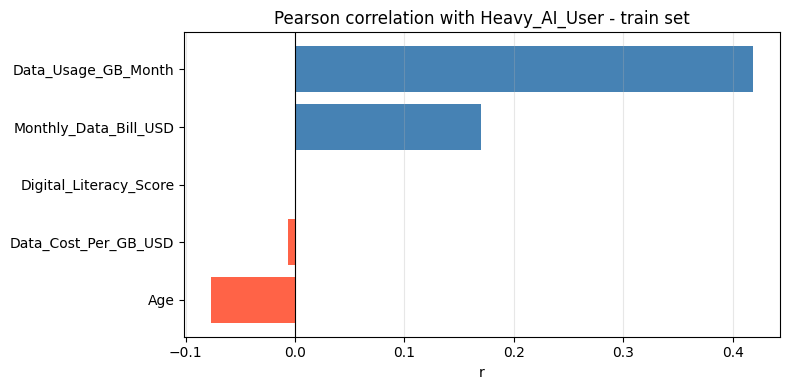

In [ ]:
# Correlations of numerical features with the target
corr_train = (
    train_eda[numeric_features + ["Heavy_AI_User"]]
    .corr(numeric_only=True)["Heavy_AI_User"]
    .drop("Heavy_AI_User")
    .sort_values()
)

display(corr_train.rename("corr_with_target").to_frame().round(4))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if value < 0 else "steelblue" for value in corr_train.values]
ax.barh(corr_train.index, corr_train.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson correlation with Heavy_AI_User - train set")
ax.set_xlabel("r")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

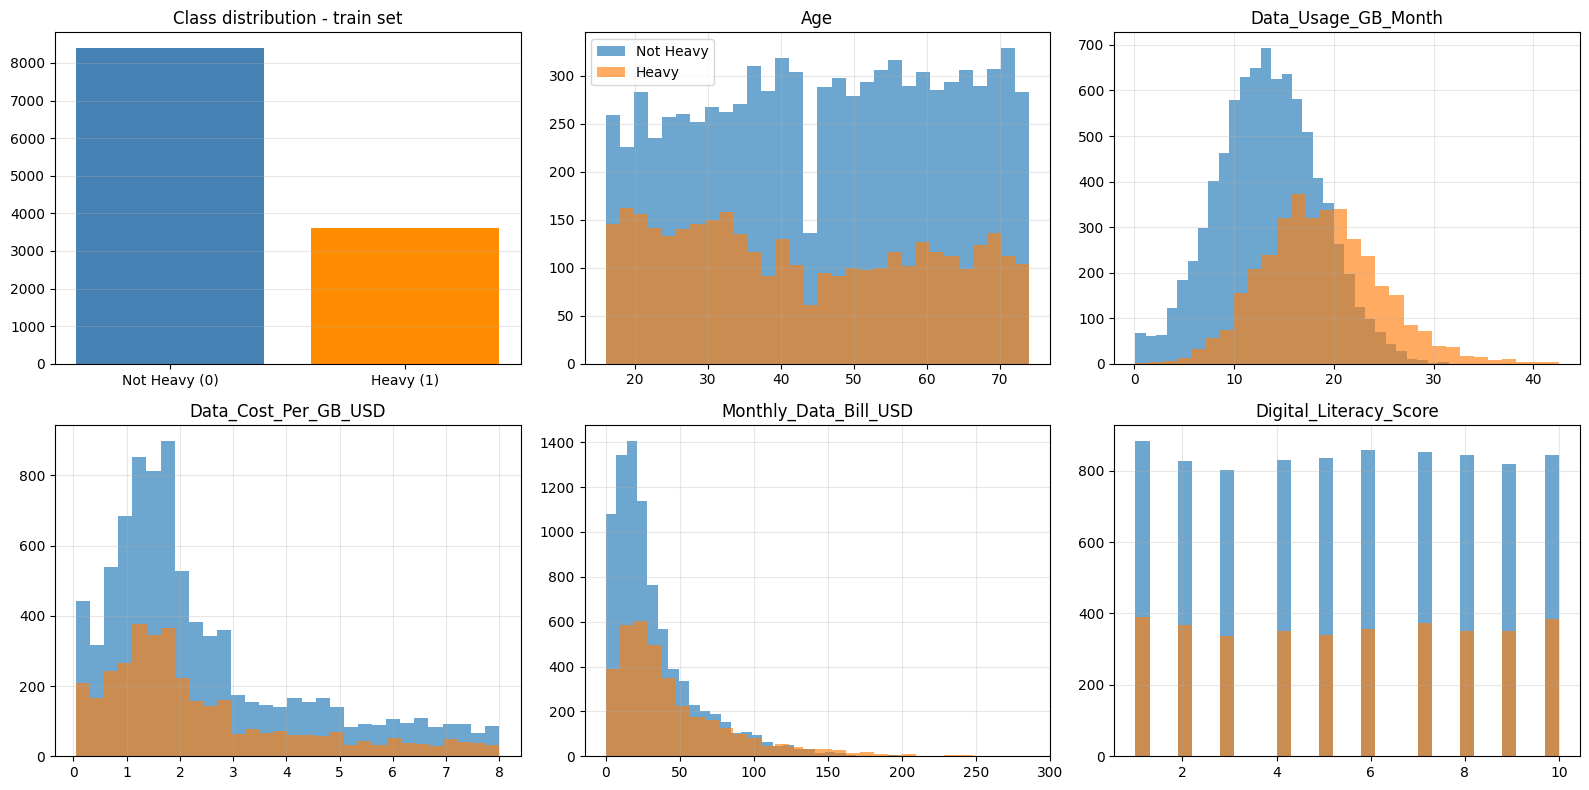

In [ ]:
# Distribution of target and basic numerical features in the train set
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

counts = y_train.value_counts().sort_index()
axes[0].bar(["Not Heavy (0)", "Heavy (1)"], counts.values, color=["steelblue", "darkorange"])
axes[0].set_title("Class distribution - train set")
axes[0].grid(axis="y", alpha=0.3)

for ax, col in zip(axes[1:], numeric_features):
    ax.hist(train_eda.loc[train_eda["Heavy_AI_User"] == 0, col], bins=30, alpha=0.65, label="Not Heavy")
    ax.hist(train_eda.loc[train_eda["Heavy_AI_User"] == 1, col], bins=30, alpha=0.65, label="Heavy")
    ax.set_title(col)
    ax.grid(alpha=0.3)

axes[1].legend()
plt.tight_layout()
plt.show()

Heavy rate per Device_Type:


,mean,count
Device_Type,,
Laptop,0.349,3002
Desktop,0.349,1177
Tablet,0.309,628
IoT Device,0.286,612
Mobile,0.270,6581



Top countries per heavy rate:


,mean,count
Country,,
Nigeria,0.325,818
Germany,0.324,757
India,0.318,861
Brazil,0.316,797
USA,0.312,808
South Korea,0.311,805
Japan,0.310,816
China,0.307,817
South Africa,0.306,817



Heavy rate per Primary_AI_Use_Case:


,mean,count
Primary_AI_Use_Case,,
Chatbots,0.347,1393
Gaming AI,0.340,1396
Healthcare Diagnosis,0.334,1319
Research,0.328,1395
Educational Tools,0.324,1379
Content Creation,0.320,1376
Coding,0.312,1308
NaN,0.186,2434


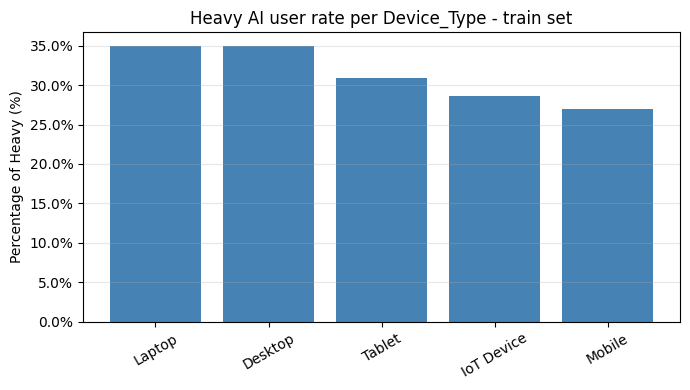

In [ ]:
# Percentage of heavy users per category
device_rate = (
    train_eda.groupby("Device_Type")["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

country_rate = (
    train_eda.groupby("Country")["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

use_case_rate = (
    train_eda.groupby("Primary_AI_Use_Case", dropna=False)["Heavy_AI_User"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

print("Heavy rate per Device_Type:")
display(device_rate.round(3))

print("\nTop countries per heavy rate:")
display(country_rate.head(10).round(3))

print("\nHeavy rate per Primary_AI_Use_Case:")
display(use_case_rate.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(device_rate.index, device_rate["mean"] * 100, color="steelblue")
ax.set_title("Heavy AI user rate per Device_Type - train set")
ax.set_ylabel("Percentage of Heavy (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Data Preprocessing

Preprocessing is implemented with **Pipeline** and **ColumnTransformer**.

1. Numerical features:
- `SimpleImputer(strategy="median")`
- `StandardScaler()`

2. Categorical features:
- `SimpleImputer(strategy="most_frequent")`
- `OneHotEncoder(handle_unknown="ignore", sparse_output=False)`

3. Imbalance:
- `class_weight="balanced"` in Logistic Regression and Random Forest

All of the above are applied within the pipelines and in each fold of the cross-validation, preprocessing only fits the training part of the fold.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Data_Usage_GB_Month',
                                  'Data_Cost_Per_GB_USD',
                                  'Monthly_Data_Bill_USD',
                                  'Digital_Literacy_Score']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Country', 'State', 'Gender', 'Device_Type',
                                  'Has_5G_Access', 'Primary_AI_Use_Case'])])

## 1.3 Model Selection and Implementation

Three models were selected:

### Model 1: Logistic Regression

Logistic Regression is a linear probabilistic classification model. It is suitable as a robust baseline, is interpreted through coefficients, and supports `class_weight="balanced"`.

### Model 2: Bernoulli Naive Bayes

Bernoulli Naive Bayes is a probabilistic model based on the assumption of conditional independence of features. After one-hot encoding, it is a reasonable baseline for categorical/binary information.

### Model 3: Random Forest

Random Forest is an ensemble of decision trees. It can capture nonlinear relationships and interactions of features. It also reduces the variance of a single tree through bagging.

In [ ]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

pipe_nb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", BernoulliNB()),
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

base_pipelines = {
    "Logistic Regression": pipe_lr,
    "Bernoulli Naive Bayes": pipe_nb,
    "Random Forest": pipe_rf,
}

base_pipelines

{'Logistic Regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['Age', 'Data_Usage_GB_Month',
                                                    'Data_Cost_Per_GB_USD',
                                                    'Monthly_Data_Bill_USD',
                                                    'Digital_Literacy_Score']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(st

## 1.4 Hyperparameter Training and Tuning

Hyperparameter selection is done with **StratifiedKFold(5)** and **scoring="roc_auc"**.

- Logistic Regression: `GridSearchCV` for **C**
- Bernoulli Naive Bayes: `GridSearchCV` for **alpha**
- Random Forest: `RandomizedSearchCV(n_iter=30)` for **n_estimators**, **max_depth**, **min_samples_leaf**, **max_features**

The parameters are written with the prefix **clf__**, because the classifier is a step in a Pipeline.

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

### Tuning 1: Logistic Regression - GridSearchCV

In [ ]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)

gs_lr.fit(X_train, y_train)

print("Best parameters:", gs_lr.best_params_)
print(f"Best CV ROC-AUC: {gs_lr.best_score_:.4f}")

Best parameters: {'clf__C': 0.01}
Best CV ROC-AUC: 0.7620


### Tuning 2: Bernoulli Naive Bayes - GridSearchCV

In [ ]:
param_grid_nb = {
    "clf__alpha": [0.01, 0.1, 0.5, 1, 2, 5],
}

gs_nb = GridSearchCV(
    estimator=pipe_nb,
    param_grid=param_grid_nb,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
)

gs_nb.fit(X_train, y_train)

print("Best parameters:", gs_nb.best_params_)
print(f"Best CV ROC-AUC: {gs_nb.best_score_:.4f}")

Best parameters: {'clf__alpha': 5}
Best CV ROC-AUC: 0.7105


### Tuning 3: Random Forest - RandomizedSearchCV

In [ ]:
param_dist_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt", 0.3],
}

# Reduce n_iter and cv for speed
rs_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
)

rs_rf.fit(X_train, y_train)

print("Best parameters:")
for key, value in rs_rf.best_params_.items():
    print(f"  {key}: {value}")
print(f"Best CV ROC-AUC: {rs_rf.best_score_:.4f}")

Best parameters:
  clf__n_estimators: 200
  clf__min_samples_leaf: 5
  clf__max_features: 0.3
  clf__max_depth: 10
Best CV ROC-AUC: 0.7579


In [ ]:
tuned_models = {
    "Logistic Regression": gs_lr.best_estimator_,
    "Bernoulli Naive Bayes": gs_nb.best_estimator_,
    "Random Forest": rs_rf.best_estimator_,
}

cv_best_scores = pd.DataFrame({
    "model": ["Logistic Regression", "Bernoulli Naive Bayes", "Random Forest"],
    "best_cv_roc_auc": [gs_lr.best_score_, gs_nb.best_score_, rs_rf.best_score_],
    "best_params": [gs_lr.best_params_, gs_nb.best_params_, rs_rf.best_params_],
})

display(cv_best_scores)

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.761995,{'clf__C': 0.01}
1,Bernoulli Naive Bayes,0.710477,{'clf__alpha': 5}
2,Random Forest,0.757898,"{'clf__n_estimators': 200, 'clf__min_samples_l..."


## 1.5 Model Evaluation
Due to 70/30 imbalance, accuracy is not enough. We emphasize:

- Recall for class 1
- Balanced Accuracy
- ROC-AUC

In parallel, we calculate precision, F1-score, classification report, confusion matrix and ROC curve.

In [ ]:
def evaluate_model(model, X_part, y_part):
    # Calculates the classification metrics
    pred = model.predict(X_part)
    proba = model.predict_proba(X_part)[:, 1]

    return {
        "Accuracy": accuracy_score(y_part, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_part, pred),
        "Precision": precision_score(y_part, pred, zero_division=0),
        "Recall": recall_score(y_part, pred, zero_division=0),
        "F1": f1_score(y_part, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_part, proba),
    }

In [ ]:
results_rows = []

for name, model in tuned_models.items():
    train_metrics = evaluate_model(model, X_train, y_train)
    test_metrics = evaluate_model(model, X_test, y_test)

    results_rows.append({"Model": name, "Split": "Train", **train_metrics})
    results_rows.append({"Model": name, "Split": "Test", **test_metrics})

results_df = pd.DataFrame(results_rows)
display(results_df.round(4))

test_results = (
    results_df[results_df["Split"] == "Test"]
    .sort_values(["ROC-AUC", "Recall", "Balanced Accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Ranking models in the test set:")
display(test_results.round(4))

,Model,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Train,0.6934,0.6896,0.4926,0.6802,0.5714,0.7654
1,Logistic Regression,Test,0.6947,0.6865,0.4938,0.6659,0.5671,0.7626
2,Bernoulli Naive Bayes,Train,0.7147,0.6145,0.5371,0.3637,0.4337,0.7217
3,Bernoulli Naive Bayes,Test,0.7160,0.6159,0.5402,0.3651,0.4358,0.7147
4,Random Forest,Train,0.7677,0.7573,0.5917,0.7315,0.6542,0.8468
5,Random Forest,Test,0.7150,0.6902,0.5212,0.6282,0.5697,0.7618


Ranking models in the test set:


,Model,Split,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Test,0.6947,0.6865,0.4938,0.6659,0.5671,0.7626
1,Random Forest,Test,0.7150,0.6902,0.5212,0.6282,0.5697,0.7618
2,Bernoulli Naive Bayes,Test,0.7160,0.6159,0.5402,0.3651,0.4358,0.7147


In [ ]:
for name, model in tuned_models.items():
    pred_test = model.predict(X_test)

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(classification_report(
        y_test,
        pred_test,
        target_names=["Not Heavy (0)", "Heavy (1)"],
        zero_division=0,
    ))


Logistic Regression
               precision    recall  f1-score   support

Not Heavy (0)       0.83      0.71      0.76      2099
    Heavy (1)       0.49      0.67      0.57       901

     accuracy                           0.69      3000
    macro avg       0.66      0.69      0.67      3000
 weighted avg       0.73      0.69      0.70      3000


Bernoulli Naive Bayes
               precision    recall  f1-score   support

Not Heavy (0)       0.76      0.87      0.81      2099
    Heavy (1)       0.54      0.37      0.44       901

     accuracy                           0.72      3000
    macro avg       0.65      0.62      0.62      3000
 weighted avg       0.69      0.72      0.70      3000


Random Forest
               precision    recall  f1-score   support

Not Heavy (0)       0.82      0.75      0.79      2099
    Heavy (1)       0.52      0.63      0.57       901

     accuracy                           0.71      3000
    macro avg       0.67      0.69      0.68      300

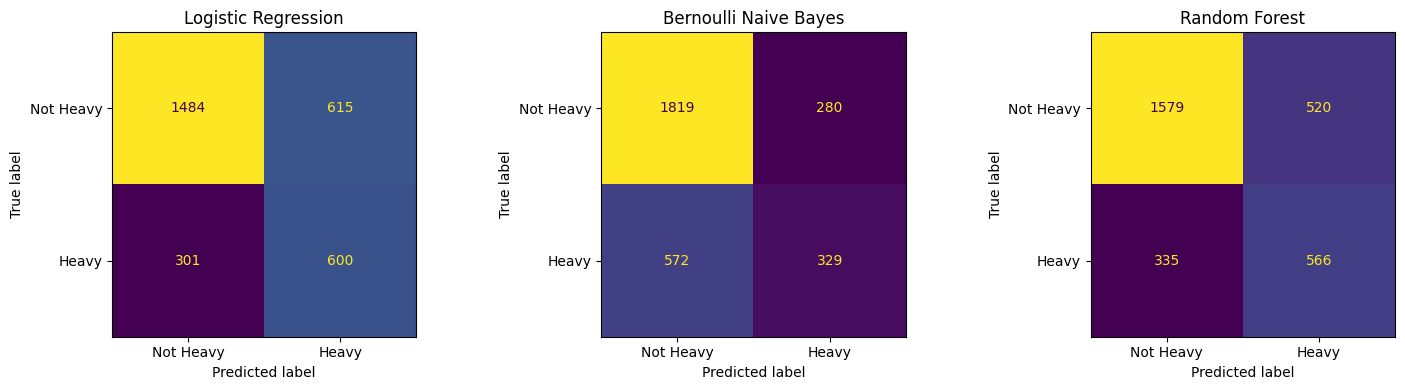

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, tuned_models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Not Heavy", "Heavy"],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

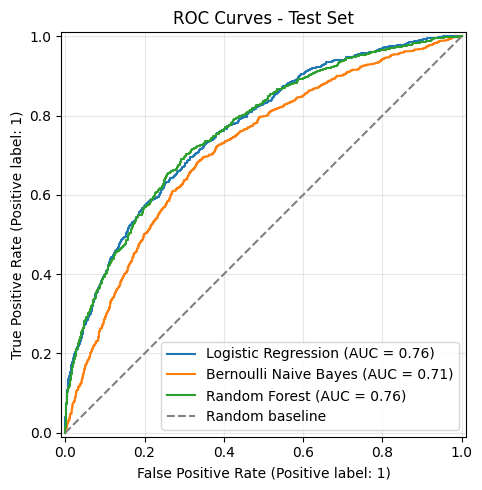

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
ax.set_title("ROC Curves - Test Set")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 1.6 Comparative Analysis of Results

### Stability - Cross-validation mean ± std

In [ ]:
stability_rows = []
scoring_map = {
    "ROC-AUC": "roc_auc",
    "Balanced Accuracy": "balanced_accuracy",
    "Recall": "recall",
}

for name, model in tuned_models.items():
    for metric_name, scoring in scoring_map.items():
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv_strategy,
            scoring=scoring,
            n_jobs=-1,
        )
        stability_rows.append({
            "Model": name,
            "Metric": metric_name,
            "CV mean": scores.mean(),
            "CV std": scores.std(),
        })

stability_df = pd.DataFrame(stability_rows)
display(stability_df.round(4))

,Model,Metric,CV mean,CV std
0,Logistic Regression,ROC-AUC,0.7620,0.0063
1,Logistic Regression,Balanced Accuracy,0.6860,0.0066
2,Logistic Regression,Recall,0.6746,0.0171
3,Bernoulli Naive Bayes,ROC-AUC,0.7105,0.0128
4,Bernoulli Naive Bayes,Balanced Accuracy,0.5997,0.0134
5,Bernoulli Naive Bayes,Recall,0.3404,0.0186
6,Random Forest,ROC-AUC,0.7576,0.0062
7,Random Forest,Balanced Accuracy,0.6798,0.0074
8,Random Forest,Recall,0.6114,0.0152


### Overfitting - Train vs Test gap

,Train ROC-AUC,Test ROC-AUC,ROC-AUC Gap,Train Balanced Accuracy,Test Balanced Accuracy,Balanced Accuracy Gap
Model,,,,,,
Logistic Regression,0.7654,0.7626,0.0028,0.6896,0.6865,0.0032
Random Forest,0.8468,0.7618,0.0850,0.7573,0.6902,0.0671
Bernoulli Naive Bayes,0.7217,0.7147,0.0070,0.6145,0.6159,-0.0013


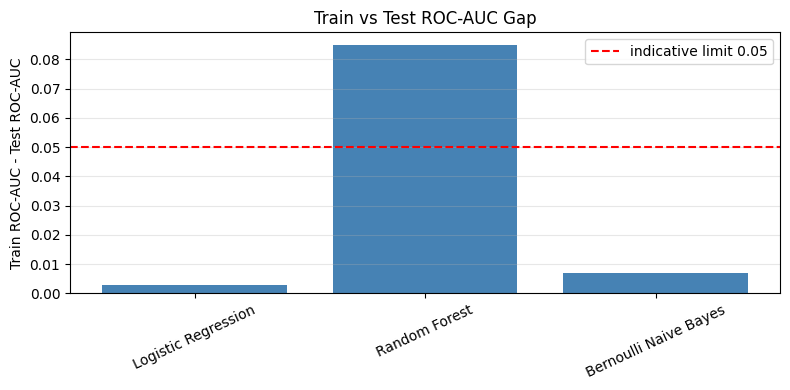

In [ ]:
train_table = results_df[results_df["Split"] == "Train"].set_index("Model")
test_table = results_df[results_df["Split"] == "Test"].set_index("Model")

gap_df = pd.DataFrame({
    "Train ROC-AUC": train_table["ROC-AUC"],
    "Test ROC-AUC": test_table["ROC-AUC"],
    "ROC-AUC Gap": train_table["ROC-AUC"] - test_table["ROC-AUC"],
    "Train Balanced Accuracy": train_table["Balanced Accuracy"],
    "Test Balanced Accuracy": test_table["Balanced Accuracy"],
    "Balanced Accuracy Gap": train_table["Balanced Accuracy"] - test_table["Balanced Accuracy"],
}).sort_values("Test ROC-AUC", ascending=False)

display(gap_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gap_df.index, gap_df["ROC-AUC Gap"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="indicative limit 0.05")
ax.set_title("Train vs Test ROC-AUC Gap")
ax.set_ylabel("Train ROC-AUC - Test ROC-AUC")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Comparison of test metrics

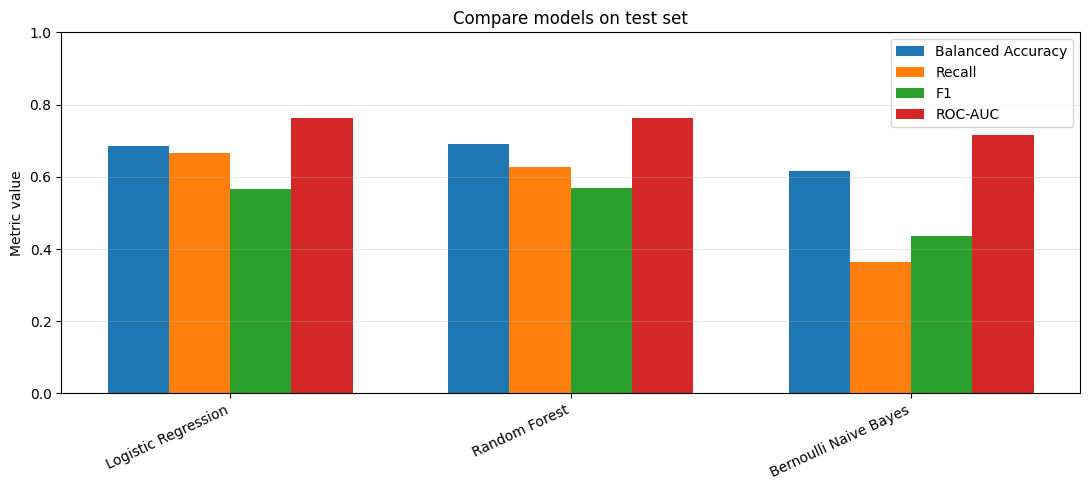

In [ ]:
plot_metrics = ["Balanced Accuracy", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(test_results["Model"]))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(plot_metrics):
    ax.bar(x + i * width, test_results[metric], width=width, label=metric)

ax.set_xticks(x + width * (len(plot_metrics) - 1) / 2)
ax.set_xticklabels(test_results["Model"], rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Metric value")
ax.set_title("Compare models on test set")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation: Who is the AI ​​heavy user?

We use two complementary approaches:

- Logistic Regression coefficients, because the model is interpretable
- Random Forest feature importances, because they show which features are most frequently used in the trees

In [ ]:
def clean_feature_name(name):
    # Clean up names from ColumnTransformer for more readable tables
    return name.replace("num__", "").replace("cat__", "")


lr_model = tuned_models["Logistic Regression"]
feature_names = lr_model.named_steps["preprocessor"].get_feature_names_out()
feature_names = [clean_feature_name(name) for name in feature_names]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lr_model.named_steps["clf"].coef_[0],
})

print("Logistic Regression - stronger positive factors:")
display(coef_df.sort_values("Coefficient", ascending=False).head(15).round(4))

print("\nLogistic Regression - ισχstronger negative factors:")
display(coef_df.sort_values("Coefficient", ascending=True).head(15).round(4))

Logistic Regression - stronger positive factors:


,Feature,Coefficient
1,Data_Usage_GB_Month,0.9893
26,State_Berlin,0.1254
117,Device_Type_Laptop,0.1210
122,Primary_AI_Use_Case_Chatbots,0.1068
115,Device_Type_Desktop,0.1067
43,State_Guangdong,0.1007
42,State_Georgia,0.0968
100,State_Telangana,0.0908
111,State_Île-de-France,0.0863
94,State_Seoul,0.0737



Logistic Regression - ισχstronger negative factors:


,Feature,Coefficient
126,Primary_AI_Use_Case_Gaming AI,-0.2654
118,Device_Type_Mobile,-0.1828
0,Age,-0.1451
76,State_Nouvelle-Aquitaine,-0.0941
73,State_North Rhine-Westphalia,-0.0875
5,Country_Australia,-0.0861
18,Country_UK,-0.0832
104,State_Victoria,-0.0783
57,State_Jiangsu,-0.0768
9,Country_France,-0.0741


Random Forest - most important features:


,Feature,Importance
1,Data_Usage_GB_Month,0.5532
3,Monthly_Data_Bill_USD,0.1104
2,Data_Cost_Per_GB_USD,0.0730
0,Age,0.0662
4,Digital_Literacy_Score,0.0260
126,Primary_AI_Use_Case_Gaming AI,0.0200
118,Device_Type_Mobile,0.0103
117,Device_Type_Laptop,0.0081
112,Gender_Female,0.0056
120,Has_5G_Access_No,0.0055


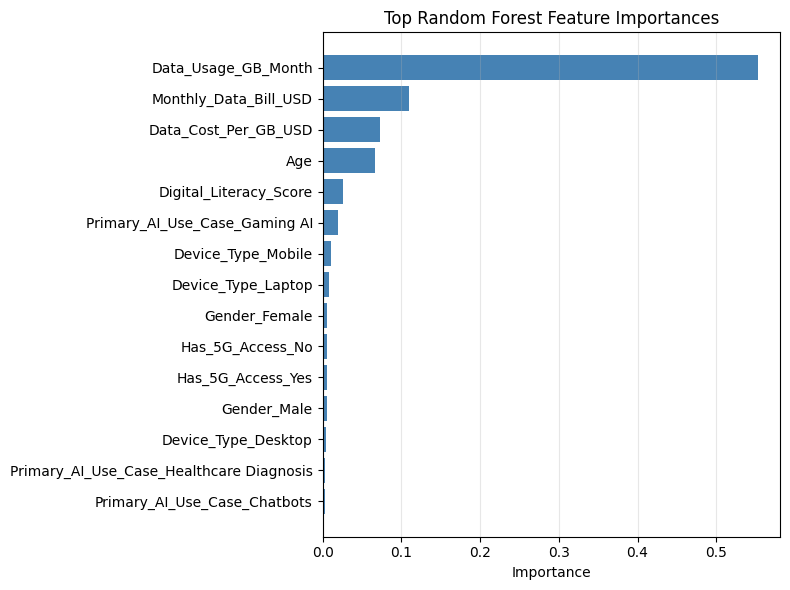

In [ ]:
rf_model = tuned_models["Random Forest"]
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_feature_names = [clean_feature_name(name) for name in rf_feature_names]

importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.named_steps["clf"].feature_importances_,
}).sort_values("Importance", ascending=False)

print("Random Forest - most important features:")
display(importance_df.head(20).round(4))

fig, ax = plt.subplots(figsize=(8, 6))
top_imp = importance_df.head(15).iloc[::-1]
ax.barh(top_imp["Feature"], top_imp["Importance"], color="steelblue")
ax.set_title("Top Random Forest Feature Importances")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Comparative Analysis Conclusions

After running the notebook, we complete the final conclusion based on the `test_results` table, `stability_df` and `gap_df`.

Criteria for selecting the best model:

- High ROC-AUC
- High Recall for the **Heavy (1)** class
- High Balanced Accuracy
- Small train-test gap
- Low standard deviation in cross-validation

In [ ]:
best_model_row = test_results.iloc[0]

print("Proposed best model based on ROC-AUC, Recall and Balanced Accuracy tests:")
print(f"Model: {best_model_row['Model']}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"Recall class 1: {best_model_row['Recall']:.4f}")
print(f"Balanced Accuracy: {best_model_row['Balanced Accuracy']:.4f}")
print(f"F1: {best_model_row['F1']:.4f}")



Proposed best model based on ROC-AUC, Recall and Balanced Accuracy tests:
Model: Logistic Regression
ROC-AUC: 0.7626
Recall class 1: 0.6659
Balanced Accuracy: 0.6865
F1: 0.5671
